# Wykład 3 — część 2: odds, regresja logistyczna, progi i ROC/AUC

Ta część kontynuuje materiał **01–16** i nie wchodzi w tematy `17_*`.

Historia części 2:

$$
\text{prawdopodobieństwo} \rightarrow \text{odds} \rightarrow \text{log-odds} \rightarrow \text{regresja logistyczna} \rightarrow \text{threshold} \rightarrow \text{ROC/AUC}
$$

Pracujemy głównie na:

- `grades.csv` — mały zbiór do odds i log-odds,
- `titanic.csv` — klasyfikacja, progi, ROC/AUC, leakage,
- `tips.csv` — krótki przykład klasyfikacji przez definicję targetu.

## Mapa logiczna tej części

Ta część odpowiada na pytanie: jak przejść od regresji do klasyfikacji bez gubienia intuicji liniowej?

| Krok | Pytanie | Odpowiedź |
|---|---|---|
| 1 | Jak opisać zdarzenie binarne? | prawdopodobieństwo $p$ |
| 2 | Jak porównywać sukcesy i porażki? | odds $p/(1-p)$ |
| 3 | Jak zrobić skalę liniową? | log-odds / logit |
| 4 | Jak dopasować model? | likelihood |
| 5 | Jak zamienić probability na decyzję? | threshold |
| 6 | Jak ocenić klasyfikator? | confusion matrix, ROC, AUC |

Najważniejszy most:

$$
\text{regresja liniowa: } \hat y = X\beta
$$

$$
\text{regresja logistyczna: } logit(p)=X\beta
$$

## Jak prowadzić tę część?

Najpierw pokazujemy, że prawdopodobieństwo jest ograniczone do przedziału $[0,1]$:

$$
0 \le p \le 1
$$

Potem przechodzimy do odds:

$$
odds = \frac{p}{1-p}
$$

a potem do log-odds:

$$
logit(p)=\log\left(\frac{p}{1-p}\right)
$$

Dzięki logitowi możemy modelować klasyfikację liniowo na skali log-odds:

$$
logit(p)=X\beta
$$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, log_loss
)

# Notebook może być uruchamiany z różnych katalogów.
# Szukamy plików w ./data, ../data i /mnt/data.
def find_data_file(filename):
    candidates = [
        Path('data') / filename,
        Path('../data') / filename,
        Path(filename),
        Path('/mnt/data') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Nie znaleziono pliku: {filename}')

# Zgodność z różnymi wersjami sklearn: OneHotEncoder zmienił sparse -> sparse_output.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

pd.set_option('display.max_columns', 40)
np.set_printoptions(precision=3, suppress=True)

from scipy.stats import fisher_exact, chi2_contingency, norm

## 1. Wczytanie danych

Bierzemy te same dane, ale zmieniamy pytanie. W części 1 przewidywaliśmy liczbę `Grade`. Tutaj pytamy:

$$
Passed = I(Grade \ge 50)
$$

czyli przechodzimy z regresji do klasyfikacji.

In [2]:
grades_raw = pd.read_csv(find_data_file('previous_lecture_grades.csv'))
titanic_raw = pd.read_csv(find_data_file('seaborn_titanic.csv'))
tips_raw = pd.read_csv(find_data_file('seaborn_tips.csv'))

grades = grades_raw.dropna(subset=['StudyHours', 'Grade']).copy()
grades['StudyHours'] = grades['StudyHours'].astype(float)
grades['Grade'] = grades['Grade'].astype(float)
grades['Passed'] = (grades['Grade'] >= 50).astype(int)

titanic = titanic_raw.copy()
tips = tips_raw.copy()

print('grades:', grades.shape)
print('titanic:', titanic.shape)
print('tips:', tips.shape)
grades.head()

grades: (22, 4)
titanic: (891, 15)
tips: (244, 7)


,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,1
1,Joann,11.50,50.0,1
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0


## 2. Probability, odds i log-odds na prostych liczbach

Prawdopodobieństwo sukcesu:

$$
p = P(Y=1)
$$

Odds:

$$
odds = \frac{p}{1-p}
$$

Log-odds:

$$
\log(odds)=\log\left(\frac{p}{1-p}\right)
$$

Ważna intuicja: prawdopodobieństwo żyje w $[0,1]$, ale log-odds żyje na całej osi rzeczywistej. Dlatego regresja logistyczna może mieć liniowy predyktor.

### Dlaczego nie modelujemy prawdopodobieństwa zwykłą prostą?

Gdybyśmy napisali:

$$
p=b_0+b_1x
$$

to dla niektórych wartości $x$ moglibyśmy dostać $p<0$ albo $p>1$. To niemożliwe, bo prawdopodobieństwo musi leżeć w przedziale:

$$
0\le p\le 1
$$

Logit rozwiązuje ten problem. Najpierw przenosi prawdopodobieństwo na całą oś:

$$
logit(p)=\log\left(\frac{p}{1-p}\right)
$$

potem modelujemy tę wartość liniowo:

$$
logit(p)=b_0+b_1x
$$

Na końcu sigmoid wraca do przedziału $[0,1]$.

In [3]:
probabilities = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

pd.DataFrame({
    'p': probabilities,
    'odds = p/(1-p)': odds,
    'log_odds': log_odds
}).round(3)

,p,odds = p/(1-p),log_odds
0,0.01,0.010,-4.595
1,0.05,0.053,-2.944
2,0.10,0.111,-2.197
3,0.25,0.333,-1.099
4,0.50,1.000,0.000
5,0.75,3.000,1.099
6,0.90,9.000,2.197
7,0.95,19.000,2.944
8,0.99,99.000,4.595


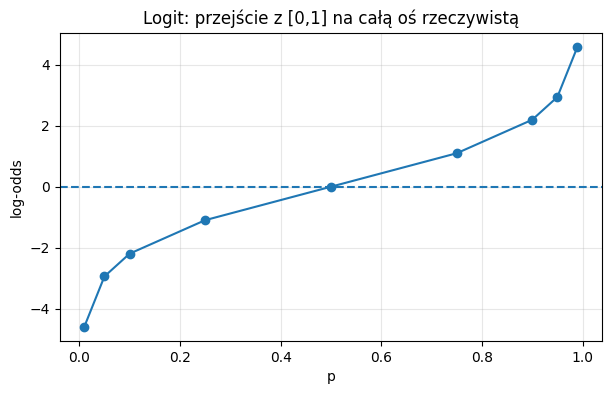

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(probabilities, log_odds, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('p')
plt.ylabel('log-odds')
plt.title('Logit: przejście z [0,1] na całą oś rzeczywistą')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Logarytm prostuje skalę odds ratio

Jeśli odds ratio zmienia się multiplikatywnie:

$$
\frac{1}{16}, \frac{1}{8}, \frac{1}{4}, \frac{1}{2}, 1, 2, 4, 8, 16
$$

to logarytm zamienia to na skalę addytywną:

$$
-2.77, -2.08, -1.39, -0.69, 0, 0.69, 1.39, 2.08, 2.77
$$

To jest dokładnie intuicja, którą omawialiśmy przy tabelce `OR` i `log(OR)`.

In [5]:
OR_values = np.array([1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16])
log_OR_values = np.log(OR_values)

or_demo = pd.DataFrame({
    'OR': OR_values,
    'log(OR)': log_OR_values,
    'różnica_log': np.r_[np.nan, np.diff(log_OR_values)]
})
or_demo.round(3)

,OR,log(OR),różnica_log
0,0.062,-2.773,NaN
1,0.125,-2.079,0.693
2,0.250,-1.386,0.693
3,0.500,-0.693,0.693
4,1.000,0.000,0.693
5,2.000,0.693,0.693
6,4.000,1.386,0.693
7,8.000,2.079,0.693
8,16.000,2.773,0.693


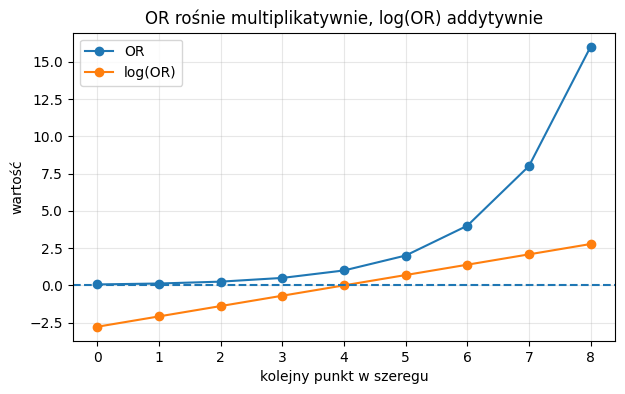

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(or_demo.index, or_demo['OR'], marker='o', label='OR')
plt.plot(or_demo.index, or_demo['log(OR)'], marker='o', label='log(OR)')
plt.axhline(0, linestyle='--')
plt.xlabel('kolejny punkt w szeregu')
plt.ylabel('wartość')
plt.title('OR rośnie multiplikatywnie, log(OR) addytywnie')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Odds ratio z `grades`: próg godzin nauki

Dzielimy studentów na dwie grupy:

$$
+ : StudyHours \ge 10
$$

$$
- : StudyHours < 10
$$

Liczymy:

$$
odds(+) = \frac{passed_+}{failed_+}
$$

$$
odds(-) = \frac{passed_-}{failed_-}
$$

oraz:

$$
OR = \frac{odds(+)}{odds(-)}
$$

Przy małych danych często dodajemy korektę $0.5$, żeby uniknąć zer i nieskończoności.

### Jak interpretować OR bez logarytmu i z logarytmem?

Jeżeli:

$$
OR=2
$$

to odds w grupie `+` są dwa razy większe niż w grupie `-`.

Jeżeli:

$$
OR=0.5
$$

to odds w grupie `+` są dwa razy mniejsze.

Na skali OR wartości 2 i 0.5 nie wyglądają symetrycznie. Po logarytmie mamy:

$$
\log(2)=0.693
$$

$$
\log(0.5)=-0.693
$$

To jest powód, dla którego w modelach i testach często pracujemy na $\log(OR)$, a nie na samym $OR$.

In [7]:
HOURS_LIMIT = 10
grades['HighHours'] = grades['StudyHours'] >= HOURS_LIMIT

table = pd.crosstab(grades['HighHours'], grades['Passed'])
table.index = [f'< {HOURS_LIMIT}h', f'>= {HOURS_LIMIT}h']
table.columns = ['failed', 'passed']
table

,failed,passed
< 10h,10,0
>= 10h,1,11


In [8]:
alpha = 0.5
passed_high = ((grades['HighHours']) & (grades['Passed'] == 1)).sum()
failed_high = ((grades['HighHours']) & (grades['Passed'] == 0)).sum()
passed_low = ((~grades['HighHours']) & (grades['Passed'] == 1)).sum()
failed_low = ((~grades['HighHours']) & (grades['Passed'] == 0)).sum()

odds_high = (passed_high + alpha) / (failed_high + alpha)
odds_low = (passed_low + alpha) / (failed_low + alpha)
OR = odds_high / odds_low
log_OR = np.log(OR)

pd.DataFrame([{
    'odds_high': odds_high,
    'odds_low': odds_low,
    'OR': OR,
    'log_OR': log_OR
}]).round(3)

,odds_high,odds_low,OR,log_OR
0,7.667,0.048,161.0,5.081


## 5. Pętla po progach: z danych do wykresu

To jest bardzo dobry fragment dydaktyczny: zmieniamy próg godzin i za każdym razem liczymy $OR$ oraz $\log(OR)$.

Celem nie jest stabilna analiza statystyczna — zbiór jest mały. Celem jest zobaczenie mechanizmu:

$$
\text{tabela 2x2} \rightarrow odds \rightarrow OR \rightarrow \log(OR)
$$

In [9]:
def smoothed_odds(passed, failed, alpha=0.5):
    return (passed + alpha) / (failed + alpha)

rows = []
for threshold in [6, 8, 9, 10, 11.5, 12, 13, 14, 15]:
    high = grades['StudyHours'] >= threshold
    passed = grades['Passed'] == 1
    ph = int((high & passed).sum())
    fh = int((high & ~passed).sum())
    pl = int((~high & passed).sum())
    fl = int((~high & ~passed).sum())
    op = smoothed_odds(ph, fh)
    om = smoothed_odds(pl, fl)
    rows.append({
        'threshold': threshold,
        'passed_high': ph,
        'failed_high': fh,
        'passed_low': pl,
        'failed_low': fl,
        'odds(+)': op,
        'odds(-)': om,
        'OR': op/om,
        'log(OR)': np.log(op/om)
    })

or_table = pd.DataFrame(rows)
or_table.round(3)

,threshold,passed_high,failed_high,passed_low,failed_low,odds(+),odds(-),OR,log(OR)
0,6.0,11,10,0,1,1.095,0.333,3.286,1.190
1,8.0,11,9,0,2,1.211,0.200,6.053,1.800
2,9.0,11,6,0,5,1.769,0.091,19.462,2.968
3,10.0,11,1,0,10,7.667,0.048,161.000,5.081
4,11.5,10,0,1,11,21.000,0.130,161.000,5.081
5,12.0,8,0,3,11,17.000,0.304,55.857,4.023
6,13.0,5,0,6,11,11.000,0.565,19.462,2.968
7,14.0,4,0,7,11,9.000,0.652,13.800,2.625
8,15.0,3,0,8,11,7.000,0.739,9.471,2.248


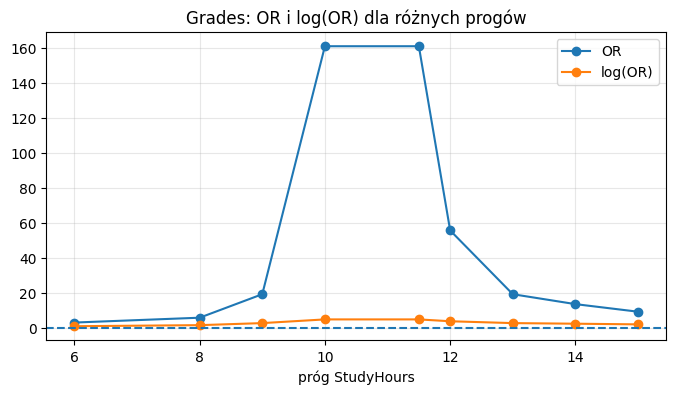

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(or_table['threshold'], or_table['OR'], marker='o', label='OR')
plt.plot(or_table['threshold'], or_table['log(OR)'], marker='o', label='log(OR)')
plt.axhline(0, linestyle='--')
plt.xlabel('próg StudyHours')
plt.title('Grades: OR i log(OR) dla różnych progów')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Fisher, chi-square i Wald na tabeli 2×2

Dla tabeli 2×2 możemy pytać, czy dwie zmienne są niezależne.

Przykład z Titanica:

$$
sex \times survived
$$

- test Fishera: dokładny test dla tabeli 2×2,
- chi-square: porównuje liczebności obserwowane z oczekiwanymi,
- Wald dla $\log(OR)$: sprawdza, czy $\log(OR)$ istotnie różni się od 0.

Nie robimy tu pełnego kursu testowania hipotez; celem jest połączenie tabeli 2×2 z log-odds i regresją logistyczną.

### Jak połączyć testy z intuicją modelowania?

Tabela 2×2 daje nam punkt startu:

$$
\begin{array}{c|cc}
 & y=1 & y=0 \\
 group=1 & a & b \\
 group=0 & c & d
\end{array}
$$

Odds ratio:

$$
OR=\frac{a/b}{c/d}=\frac{ad}{bc}
$$

Test Fishera i chi-square pytają, czy związek w tabeli może być przypadkowy. Test Walda dla $\log(OR)$ robi podobną rzecz na skali, która jest naturalna dla regresji logistycznej.

Regresja logistyczna uogólnia tę logikę: zamiast jednej tabeli 2×2 możemy mieć wiele cech jednocześnie.

In [11]:
tab_sex = pd.crosstab(titanic['sex'], titanic['survived'])
tab_sex.columns = ['not_survived', 'survived']
tab_sex

,not_survived,survived
sex,,
female,81,233
male,468,109


In [12]:
# Ustawiamy tabelę jako [[a,b],[c,d]]
# a = female survived, b = female not survived, c = male survived, d = male not survived
female_surv = tab_sex.loc['female', 'survived']
female_dead = tab_sex.loc['female', 'not_survived']
male_surv = tab_sex.loc['male', 'survived']
male_dead = tab_sex.loc['male', 'not_survived']

odds_female = female_surv / female_dead
odds_male = male_surv / male_dead
OR_female_vs_male = odds_female / odds_male
log_OR = np.log(OR_female_vs_male)

# SE log(OR) dla tabeli 2x2
se_log_or = np.sqrt(1/female_surv + 1/female_dead + 1/male_surv + 1/male_dead)
z = log_OR / se_log_or
p_wald = 2 * (1 - norm.cdf(abs(z)))

fisher_or, fisher_p = fisher_exact([[female_surv, female_dead], [male_surv, male_dead]])
chi2, chi_p, dof, expected = chi2_contingency(tab_sex.to_numpy())

pd.DataFrame([{
    'odds_female': odds_female,
    'odds_male': odds_male,
    'OR_female_vs_male': OR_female_vs_male,
    'log_OR': log_OR,
    'z_Wald': z,
    'p_Wald': p_wald,
    'p_Fisher': fisher_p,
    'chi2': chi2,
    'p_chi2': chi_p
}]).round(4)

,odds_female,odds_male,OR_female_vs_male,log_OR,z_Wald,p_Wald,p_Fisher,chi2,p_chi2
0,2.8765,0.2329,12.3507,2.5137,15.0361,0.0,0.0,260.717,0.0


## 7. Regresja logistyczna: log-odds jako linia

Regresja logistyczna zakłada:

$$
logit(p_i)=\log\left(\frac{p_i}{1-p_i}\right)=b_0+b_1x_i
$$

Po przekształceniu:

$$
p_i = \frac{1}{1+e^{-(b_0+b_1x_i)}}
$$

Czyli:

- na skali log-odds model jest linią,
- na skali prawdopodobieństwa model jest krzywą sigmoid.

### Co oznacza współczynnik w regresji logistycznej?

Dla modelu:

$$
logit(p)=b_0+b_1x
$$

współczynnik $b_1$ mówi, o ile zmieniają się log-odds po zwiększeniu $x$ o 1:

$$
\Delta logit(p)=b_1
$$

Po eksponentacji:

$$
\exp(b_1)
$$

dostajemy mnożnik odds. Jeśli $\exp(b_1)=1.5$, to wzrost $x$ o 1 mnoży odds przez 1.5. Jeśli $\exp(b_1)=0.7$, to odds są mnożone przez 0.7, czyli maleją.

To jest centralna interpretacja regresji logistycznej.

In [13]:
Xg = grades[['StudyHours']]
yg = grades['Passed']
log_grades = LogisticRegression()
log_grades.fit(Xg, yg)

b0 = log_grades.intercept_[0]
b1 = log_grades.coef_[0][0]

print(f'logit(p) = {b0:.3f} + {b1:.3f} * StudyHours')
print(f'exp(b1) = {np.exp(b1):.3f}  # mnożnik odds dla +1 godziny')

logit(p) = -16.103 + 1.559 * StudyHours
exp(b1) = 4.753  # mnożnik odds dla +1 godziny


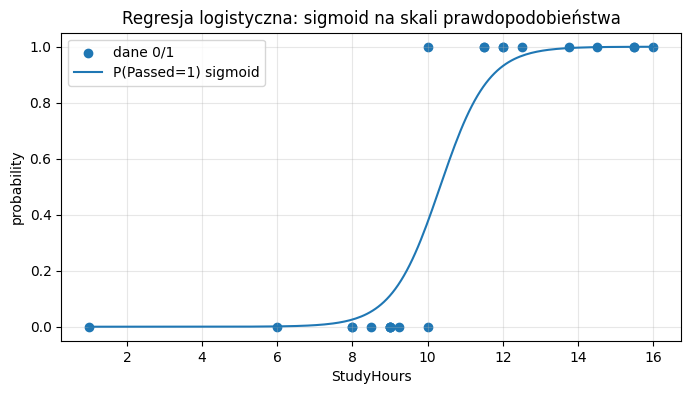

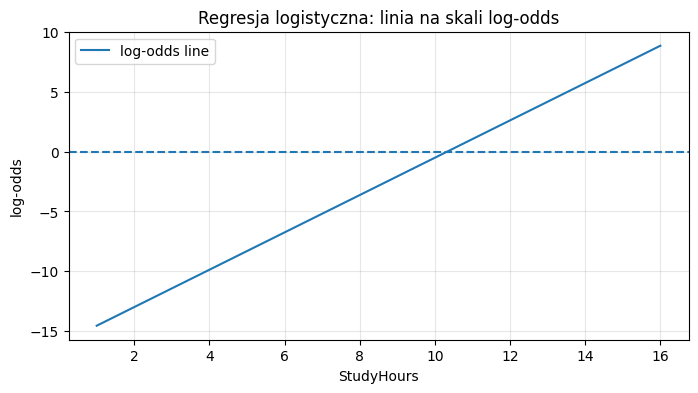

In [14]:
hours_grid = np.linspace(grades['StudyHours'].min(), grades['StudyHours'].max(), 200)
log_odds_line = b0 + b1 * hours_grid
prob_curve = 1 / (1 + np.exp(-log_odds_line))

plt.figure(figsize=(8, 4))
plt.scatter(grades['StudyHours'], grades['Passed'], label='dane 0/1')
plt.plot(hours_grid, prob_curve, label='P(Passed=1) sigmoid')
plt.xlabel('StudyHours')
plt.ylabel('probability')
plt.title('Regresja logistyczna: sigmoid na skali prawdopodobieństwa')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hours_grid, log_odds_line, label='log-odds line')
plt.axhline(0, linestyle='--')
plt.xlabel('StudyHours')
plt.ylabel('log-odds')
plt.title('Regresja logistyczna: linia na skali log-odds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Likelihood, deviance i pseudo-$R^2$

Regresja logistyczna nie minimalizuje RSS jak regresja liniowa. Maksymalizuje likelihood.

Dla obserwacji binarnej:

$$
L_i = p_i^{y_i}(1-p_i)^{1-y_i}
$$

Log-likelihood:

$$
\ell = \sum_i \left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

Deviance to w uproszczeniu kara za złe dopasowanie:

$$
D = -2\ell
$$

Pseudo-$R^2$ McFaddena:

$$
R^2_{McFadden}=1-\frac{\ell_{model}}{\ell_{null}}
$$

### Dlaczego likelihood zamiast RSS?

W regresji liniowej target jest liczbowy i sensowne jest mierzenie pionowej odległości:

$$
y_i-\hat y_i
$$

W klasyfikacji target to 0/1, a model zwraca prawdopodobieństwo. Nie chcemy minimalizować odległości od punktu 0/1 zwykłą prostą, tylko chcemy, aby model dawał wysokie prawdopodobieństwo zdarzeniom, które naprawdę zaszły.

Jeśli $y_i=1$, chcemy duże $p_i$. Jeśli $y_i=0$, chcemy duże $1-p_i$. Stąd likelihood:

$$
L_i=p_i^{y_i}(1-p_i)^{1-y_i}
$$

Log-likelihood zamienia mnożenie wielu obserwacji na sumę, co jest stabilniejsze numerycznie i wygodniejsze matematycznie.

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return np.sum(y*np.log(p) + (1-y)*np.log(1-p))

p_model = log_grades.predict_proba(Xg)[:, 1]
ll_model = log_likelihood(yg.to_numpy(), p_model)

p_null = np.repeat(yg.mean(), len(yg))
ll_null = log_likelihood(yg.to_numpy(), p_null)

pseudo_r2 = 1 - ll_model/ll_null

pd.DataFrame([{
    'll_null': ll_null,
    'll_model': ll_model,
    'deviance_null': -2*ll_null,
    'deviance_model': -2*ll_model,
    'pseudo_R2_McFadden': pseudo_r2
}]).round(4)

,ll_null,ll_model,deviance_null,deviance_model,pseudo_R2_McFadden
0,-15.2492,-2.6883,30.4985,5.3766,0.8237


## 9. Titanic: pełniejszy model logistyczny

Teraz przechodzimy do bardziej realistycznego problemu klasyfikacji:

$$
y = survived
$$

Cechy:

- liczbowe: `age`, `fare`, `sibsp`, `parch`,
- kategoryczne: `sex`, `pclass`, `embarked`.

Używamy pipeline'u, aby nie mieszać preprocessingu z testem.

In [16]:
features_num = ['age', 'fare', 'sibsp', 'parch']
features_cat = ['sex', 'pclass', 'embarked']

X = titanic[features_num + features_cat]
y = titanic['survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), features_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe())
    ]), features_cat)
])

logit_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

logit_pipe.fit(X_train, y_train)
y_score = logit_pipe.predict_proba(X_test)[:, 1]
y_pred_05 = (y_score >= 0.5).astype(int)

pd.DataFrame([{
    'accuracy': accuracy_score(y_test, y_pred_05),
    'precision': precision_score(y_test, y_pred_05),
    'recall': recall_score(y_test, y_pred_05),
    'F1': f1_score(y_test, y_pred_05),
    'AUC': roc_auc_score(y_test, y_score)
}]).round(3)

,accuracy,precision,recall,F1,AUC
0,0.799,0.758,0.699,0.727,0.849


In [17]:
cm = confusion_matrix(y_test, y_pred_05)
pd.DataFrame(
    cm,
    index=['actual 0: not survived', 'actual 1: survived'],
    columns=['pred 0', 'pred 1']
)

,pred 0,pred 1
actual 0: not survived,142,23
actual 1: survived,31,72


## 10. Threshold: probability to jeszcze nie decyzja

Model zwraca prawdopodobieństwo:

$$
p_i=P(y_i=1|X_i)
$$

Decyzja wymaga progu:

$$
\hat y_i = I(p_i \ge t)
$$

Próg $0.5$ jest domyślny, ale nie zawsze najlepszy. Zmiana progu przesuwa kompromis między precision i recall.

### Threshold jako decyzja praktyczna, nie matematyczna konieczność

Model logistyczny zwraca score albo prawdopodobieństwo. Próg decyzyjny to osobna decyzja:

$$
\hat y=I(p\ge t)
$$

W zadaniach medycznych często wolimy niski próg, żeby zwiększyć recall. W zadaniach, gdzie false positive jest kosztowny, możemy wybrać wyższy próg.

Dlatego threshold powinien wynikać z kosztów błędów:

$$
Cost = FP\cdot Cost_{FP}+FN\cdot Cost_{FN}
$$

Domyślne $0.5$ jest tylko punktem startowym.

In [18]:
def threshold_metrics(y_true, y_score, thresholds):
    rows = []
    for t in thresholds:
        pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rows.append({
            'threshold': t,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn,
            'accuracy': accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'F1': f1_score(y_true, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

thr_table = threshold_metrics(y_test, y_score, [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
thr_table.round(3)

,threshold,TP,FP,TN,FN,accuracy,precision,recall,F1
0,0.2,88,63,102,15,0.709,0.583,0.854,0.693
1,0.3,85,42,123,18,0.776,0.669,0.825,0.739
2,0.4,82,31,134,21,0.806,0.726,0.796,0.759
3,0.5,72,23,142,31,0.799,0.758,0.699,0.727
4,0.6,66,12,153,37,0.817,0.846,0.641,0.729
5,0.7,55,6,159,48,0.799,0.902,0.534,0.671
6,0.8,37,3,162,66,0.743,0.925,0.359,0.517


## 11. ROC i AUC

ROC liczy pary:

$$
FPR = \frac{FP}{FP+TN}
$$

$$
TPR = Recall = \frac{TP}{TP+FN}
$$

AUC to pole pod krzywą ROC. Intuicyjnie: jak dobrze model ustawia pozytywne przykłady wyżej niż negatywne.

Ważne: AUC nie wybiera progu. AUC ocenia ranking score'ów.

### AUC jako interpretacja rankingowa

AUC można interpretować jako prawdopodobieństwo, że losowy przykład pozytywny dostanie wyższy score niż losowy przykład negatywny.

Czyli jeżeli:

$$
AUC=0.85
$$

to model ma dobry ranking: zwykle osoby z klasy 1 są ustawiane wyżej niż osoby z klasy 0.

Ale AUC nie mówi, który próg wybrać. Model z wysokim AUC nadal może mieć słabą precision albo recall przy źle dobranym progu.

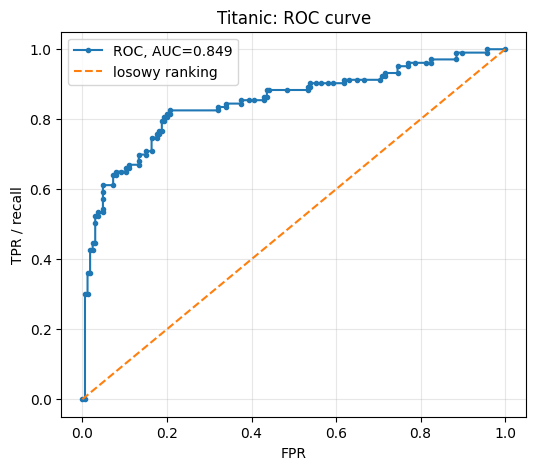

,threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.971110,0.006061,0.000000
2,0.856480,0.006061,0.300971
3,0.845990,0.012121,0.300971
4,0.823325,0.012121,0.359223
5,0.801761,0.018182,0.359223
6,0.780458,0.018182,0.427184
7,0.778724,0.024242,0.427184
8,0.766969,0.024242,0.446602
9,0.739810,0.030303,0.446602


In [19]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
auc_val = roc_auc_score(y_test, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, marker='o', markersize=3, label=f'ROC, AUC={auc_val:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='losowy ranking')
plt.xlabel('FPR')
plt.ylabel('TPR / recall')
plt.title('Titanic: ROC curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({'threshold': roc_thresholds, 'FPR': fpr, 'TPR': tpr}).head(10)

## 12. Leakage na Titanicu: `alive` jako zakazana cecha

W Titanicu kolumna `alive` jest tekstową wersją targetu `survived`. Jeśli użyjemy jej jako cechy, model dostaje odpowiedź.

To klasyczny leakage:

$$
X = [\text{normalne cechy}, \text{kopia targetu}]
$$

Taki wynik może być niemal idealny, ale nie jest uczciwą predykcją.

### Dlaczego leakage jest szczególnie zdradliwy w klasyfikacji?

W klasyfikacji leakage często daje niemal perfekcyjne metryki:

$$
accuracy \approx 1, \quad AUC \approx 1
$$

To wygląda świetnie, ale jest fałszywym sukcesem. Model nie nauczył się zależności przyczynowej ani predykcyjnej. Po prostu dostał informację, która w realnym momencie predykcji nie byłaby dostępna.

Dlatego przy każdym bardzo dobrym wyniku trzeba zadać pytanie:

> Czy cechy są naprawdę dostępne przed decyzją?

In [20]:
X_leak = titanic[features_num + features_cat + ['alive']]
features_cat_leak = features_cat + ['alive']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y, test_size=0.30, random_state=42, stratify=y
)

preprocess_leak = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), features_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe())
    ]), features_cat_leak)
])

leak_pipe = Pipeline([
    ('preprocess', preprocess_leak),
    ('model', LogisticRegression(max_iter=1000))
])

leak_pipe.fit(X_train_l, y_train_l)
y_score_l = leak_pipe.predict_proba(X_test_l)[:, 1]
y_pred_l = (y_score_l >= 0.5).astype(int)

pd.DataFrame([
    {'model': 'uczciwy Titanic model', 'accuracy': accuracy_score(y_test, y_pred_05), 'AUC': roc_auc_score(y_test, y_score)},
    {'model': 'model z leakage: alive', 'accuracy': accuracy_score(y_test_l, y_pred_l), 'AUC': roc_auc_score(y_test_l, y_score_l)}
]).round(3)

,model,accuracy,AUC
0,uczciwy Titanic model,0.799,0.849
1,model z leakage: alive,1.000,1.000


## 13. Tips jako klasyfikacja: target zależy od definicji

Możemy zamienić `tips` na klasyfikację, definiując:

$$
large\_tip = I(tip\_percent \ge 0.18)
$$

To ważna lekcja: w klasyfikacji target często nie jest „naturalny”, tylko wynika z decyzji analitycznej.

Inny próg oznacza inne zadanie.

In [21]:
tips = tips.copy()
tips['tip_percent'] = tips['tip'] / tips['total_bill']
tips['large_tip'] = (tips['tip_percent'] >= 0.18).astype(int)

X_tip = tips[['total_bill', 'size', 'sex', 'smoker', 'day', 'time']]
y_tip = tips['large_tip']

num_tip = ['total_bill', 'size']
cat_tip = ['sex', 'smoker', 'day', 'time']

preprocess_tip = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_tip),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe())
    ]), cat_tip),
])

Xtr, Xte, ytr, yte = train_test_split(X_tip, y_tip, test_size=0.30, random_state=42, stratify=y_tip)

tip_pipe = Pipeline([
    ('preprocess', preprocess_tip),
    ('model', LogisticRegression(max_iter=1000))
])
tip_pipe.fit(Xtr, ytr)
score_tip = tip_pipe.predict_proba(Xte)[:, 1]
pred_tip = (score_tip >= 0.5).astype(int)

pd.DataFrame([{
    'positive_rate_large_tip': y_tip.mean(),
    'accuracy': accuracy_score(yte, pred_tip),
    'precision': precision_score(yte, pred_tip, zero_division=0),
    'recall': recall_score(yte, pred_tip, zero_division=0),
    'F1': f1_score(yte, pred_tip, zero_division=0),
    'AUC': roc_auc_score(yte, score_tip)
}]).round(3)

,positive_rate_large_tip,accuracy,precision,recall,F1,AUC
0,0.32,0.676,0.0,0.0,0.0,0.5


## 14. GeoGebra checkpoint dla części 2

Do tej części można użyć GeoGebry jako tablicy intuicji:

1. narysować sigmoidę,
2. przesuwać próg decyzyjny,
3. pokazywać zmianę confusion matrix,
4. pokazywać, że log-odds są linią, a probability jest krzywą,
5. wrócić do tabeli OR i $\log(OR)$.

Jeśli korzystasz z pliku `Dopasowanie_prostej_odleglosci_normy_pogladowo.ggb`, użyj go głównie do części liniowej i reszt. Dla logistyki najlepiej zrobić osobny szkic: linia log-odds + sigmoid + próg.

## 15. Checklista po części 2

Student powinien umieć odpowiedzieć:

1. Czym różni się probability od odds?
2. Dlaczego $\log(OR)$ jest wygodniejsze niż samo $OR$?
3. Co znaczy współczynnik regresji logistycznej na skali log-odds?
4. Co znaczy `exp(coef)`?
5. Dlaczego likelihood zastępuje RSS w regresji logistycznej?
6. Co oznaczają TP, TN, FP, FN?
7. Jak próg zmienia precision i recall?
8. Co mierzy AUC?
9. Dlaczego `alive` w Titanicu to leakage?

To jest koniec aktualnego zakresu. Nie wchodzimy jeszcze w drzewa, KNN, SVM ani modele ensemble.